<a href="https://colab.research.google.com/github/ChamaniS/SkyPredictor/blob/main/SkyPredictor%5Bweatherdata_Analysis%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Imports and notebook setup**

In [1]:
# =========================
# 1. IMPORTS
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import country_converter as coco
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Libraries loaded successfully.")

Libraries loaded successfully.


**Load the data**

In [2]:
# =========================
# 2. LOAD THE DATA
# =========================

file_path = "GlobalWeatherRepository.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (137023, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137023 entries, 0 to 137022
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       137023 non-null  object 
 1   location_name                 137023 non-null  object 
 2   latitude                      137023 non-null  float64
 3   longitude                     137023 non-null  float64
 4   timezone                      137023 non-null  object 
 5   last_updated_epoch            137023 non-null  int64  
 6   last_updated                  137023 non-null  object 
 7   temperature_celsius           137023 non-null  float64
 8   temperature_fahrenheit        137023 non-null  float64
 9   condition_text                137023 non-null  object 
 10  wind_mph                      137023 non-null  float64
 11  wind_kph                      137023 non-null  float64
 12  wind_degree                   137023 non-nul

None

**Quick inspection of the data**

In [3]:
# =========================
# 3. QUICK INSPECTION
# =========================

print("Columns:")
print(df.columns.tolist())

print("\nMissing values (%):")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic summary:")
display(df.describe(include="all").T)

Columns:
['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']

Missing values (%):
Series([], dtype: float64)

Duplicate rows: 0

Basic summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,137023,211,Bulgaria,1625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,137023,257,Sanaa,705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,137023.0,NaN,NaN,NaN,19.211733,24.415744,-41.3,4.0503,17.25,40.4,64.15
longitude,137023.0,NaN,NaN,NaN,21.954979,65.786767,-175.2,-6.8361,23.2361,49.8822,179.22
timezone,137023,199,Asia/Bangkok,2523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_updated_epoch,137023.0,NaN,NaN,NaN,1746342383.092619,17598846.545131,1715849100.0,1731142800.0,1746348300.0,1761552000.0,1776839400.0
last_updated,137023,22813,2026-01-02 08:15,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_celsius,137023.0,NaN,NaN,NaN,21.263721,9.684667,-29.8,15.9,23.9,28.0,49.2
temperature_fahrenheit,137023.0,NaN,NaN,NaN,70.276475,17.432262,-21.6,60.6,75.1,82.4,120.6
condition_text,137023,49,Partly cloudy,39462,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Data cleaning and preprocessing**

*   Handle missing values, outliers, and normalize data.

In [4]:
# =========================
# 4. CLEANING
# =========================

# Make a copy of the dataframe
data = df.copy()

# Parse dates
data["last_updated"] = pd.to_datetime(data["last_updated"], errors="coerce")
data["date"] = data["last_updated"].dt.date
data["date"] = pd.to_datetime(data["date"])

# Create useful time features
data["year"] = data["last_updated"].dt.year
data["month"] = data["last_updated"].dt.month
data["day"] = data["last_updated"].dt.day
data["dayofweek"] = data["last_updated"].dt.dayofweek
data["dayofyear"] = data["last_updated"].dt.dayofyear
data["hour"] = data["last_updated"].dt.hour

# Drop duplicates
data = data.drop_duplicates()

# Convert obvious numeric columns safely
numeric_cols = [
    "latitude", "longitude", "last_updated_epoch",
    "temperature_celsius", "temperature_fahrenheit",
    "wind_mph", "wind_kph", "wind_degree",
    "pressure_mb", "pressure_in",
    "precip_mm", "precip_in",
    "humidity", "cloud",
    "feels_like_celsius", "feels_like_fahrenheit",
    "visibility_km", "visibility_miles",
    "uv_index", "gust_mph", "gust_kph",
    "air_quality_Carbon_Monoxide", "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide", "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5", "air_quality_PM10",
    "air_quality_us-epa-index", "air_quality_gb-defra-index",
    "moon_illumination"
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Remove impossible values if any
data.loc[(data["humidity"] < 0) | (data["humidity"] > 100), "humidity"] = np.nan
data.loc[(data["cloud"] < 0) | (data["cloud"] > 100), "cloud"] = np.nan
data.loc[(data["precip_mm"] < 0), "precip_mm"] = np.nan
data.loc[(data["pressure_mb"] < 800) | (data["pressure_mb"] > 1100), "pressure_mb"] = np.nan

# Fill missing numeric values with median
for col in numeric_cols:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].median())

# Fill missing categorical values
cat_cols = ["country", "location_name", "timezone", "condition_text", "wind_direction", "moon_phase"]
for col in cat_cols:
    if col in data.columns:
        data[col] = data[col].fillna("Unknown")

print("Cleaned shape:", data.shape)
display(data.head())

Cleaned shape: (137023, 48)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,date,year,month,day,dayofweek,dayofyear,hour
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24.0,30.0,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024-05-16,2024,5,16,3,137,13
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94.0,75.0,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55,2024-05-16,2024,5,16,3,137,10
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29.0,0.0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55,2024-05-16,2024,5,16,3,137,9
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61.0,100.0,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55,2024-05-16,2024,5,16,3,137,10
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89.0,50.0,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55,2024-05-16,2024,5,16,3,137,9


**Outlier handling**

In [5]:
# =========================
# 5. OUTLIER HANDLING
# =========================

def iqr_clip(df, cols, factor=1.5):
    out = df.copy()
    for col in cols:
        q1 = out[col].quantile(0.25)
        q3 = out[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        out[col] = out[col].clip(lower, upper)
    return out

clip_cols = [
    "temperature_celsius", "wind_mph", "pressure_mb", "precip_mm",
    "humidity", "cloud", "feels_like_celsius", "visibility_km", "uv_index",
    "gust_mph", "air_quality_PM2.5", "air_quality_PM10"
]

data = iqr_clip(data, clip_cols)

print("Outlier clipping done.")

Outlier clipping done.


**Basic Exploratory Data Analysis**

*   Perform basic EDA to uncover the trends, correlations, and patterns.
*   Generate visualizations for temperature and precipitation.

No missing values after cleaning.


<Figure size 1400x500 with 0 Axes>

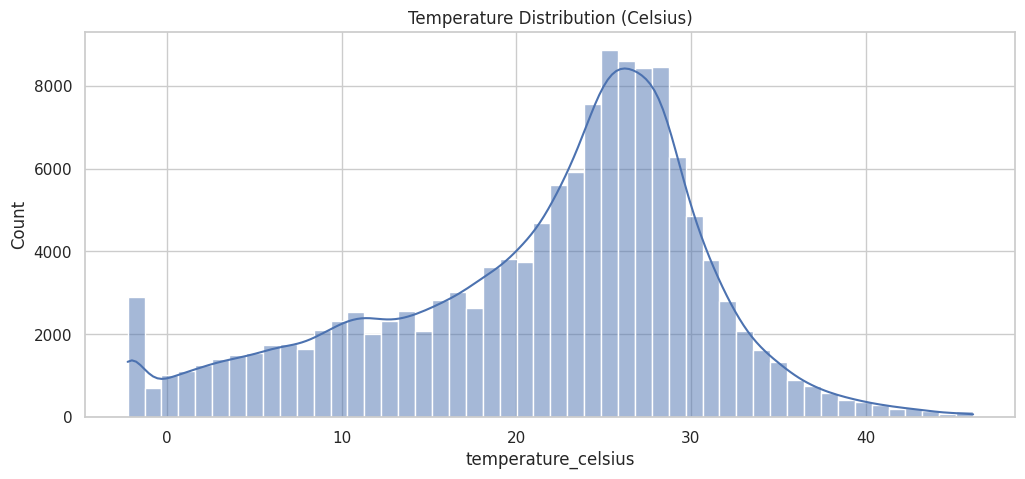

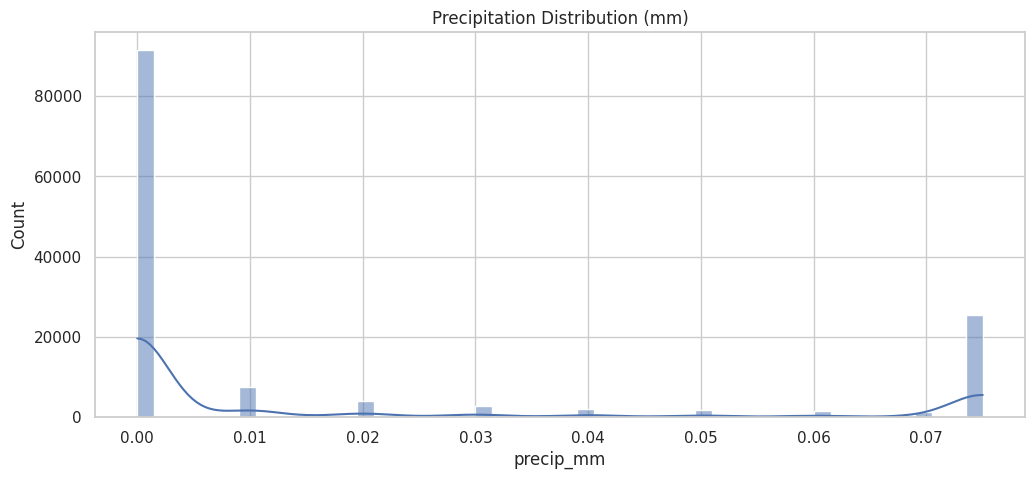

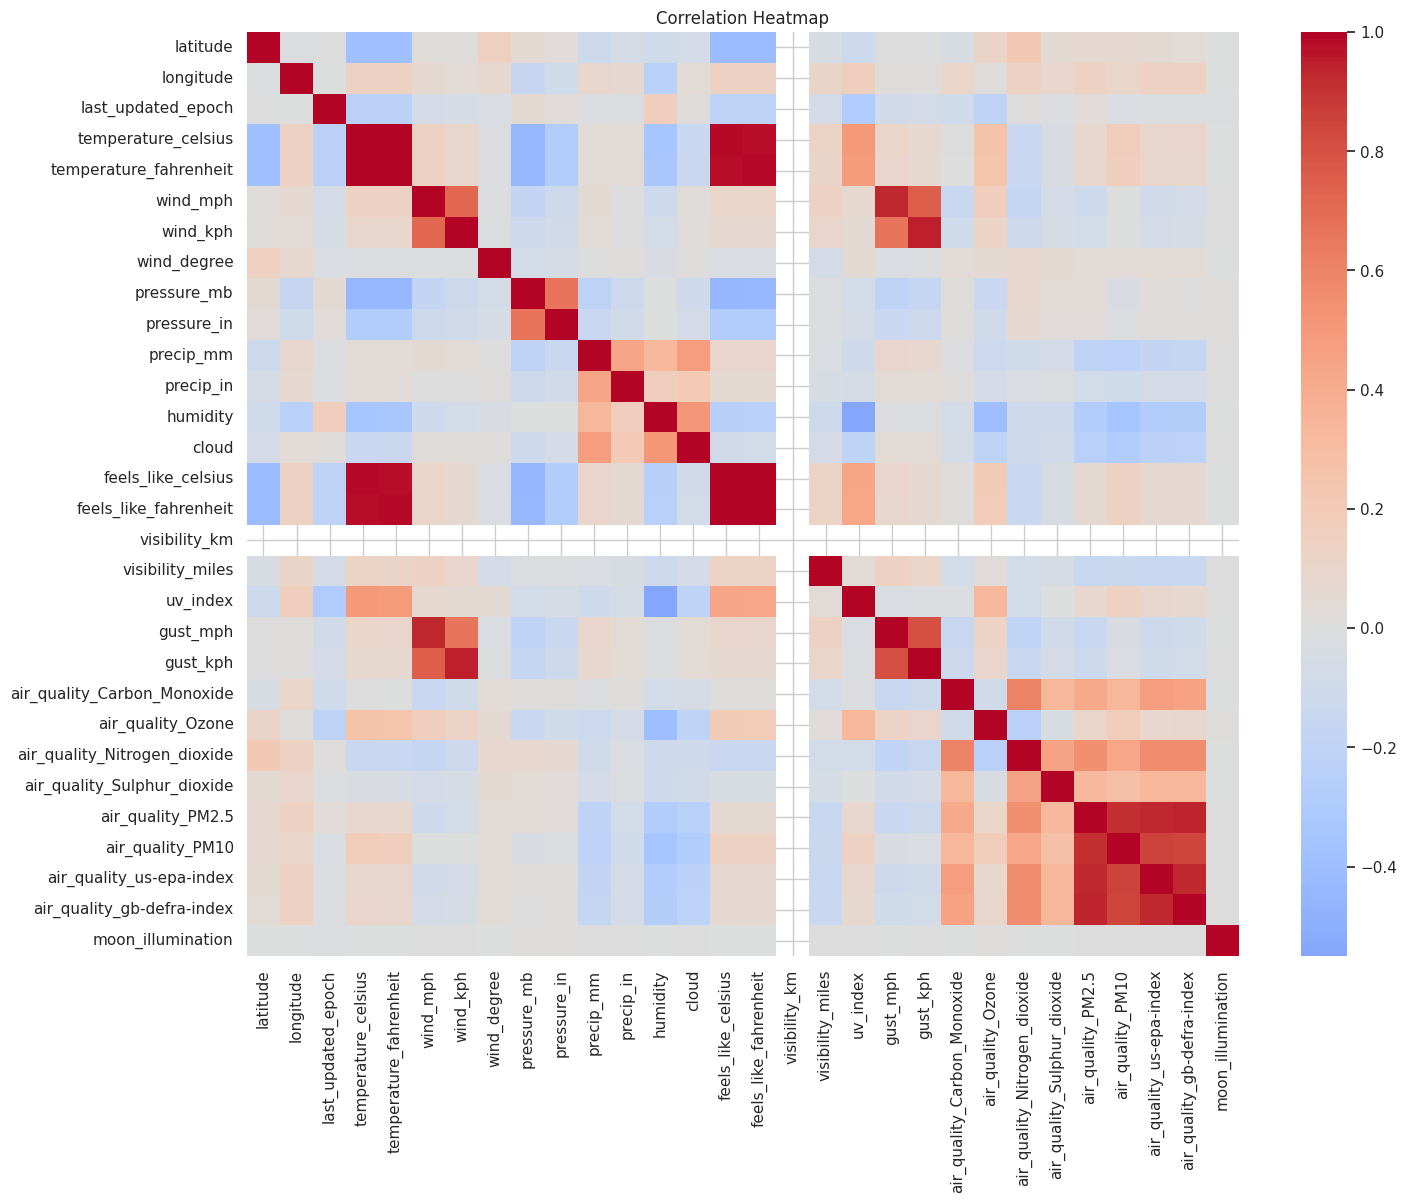

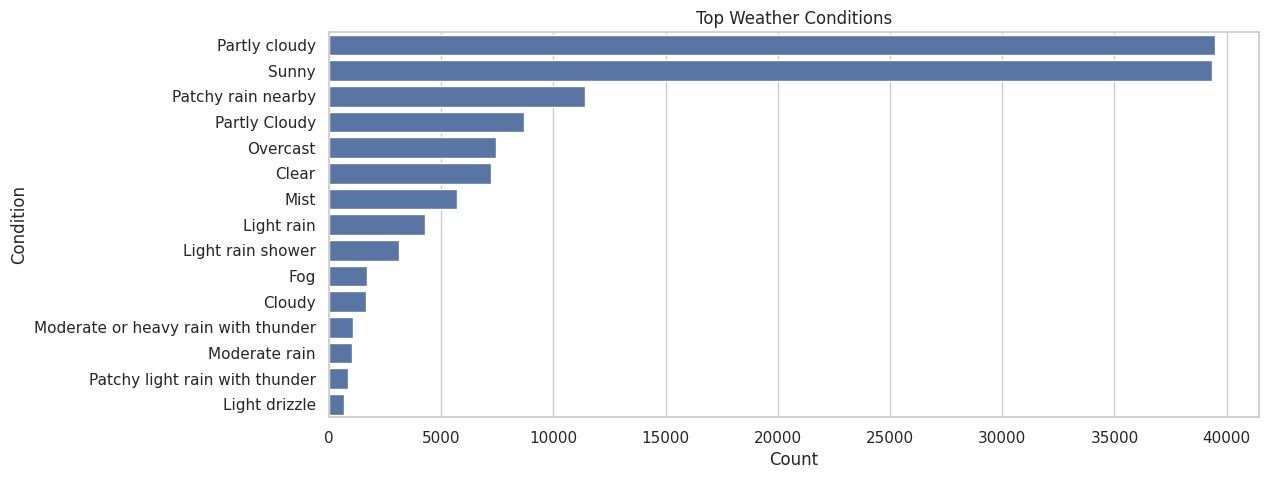

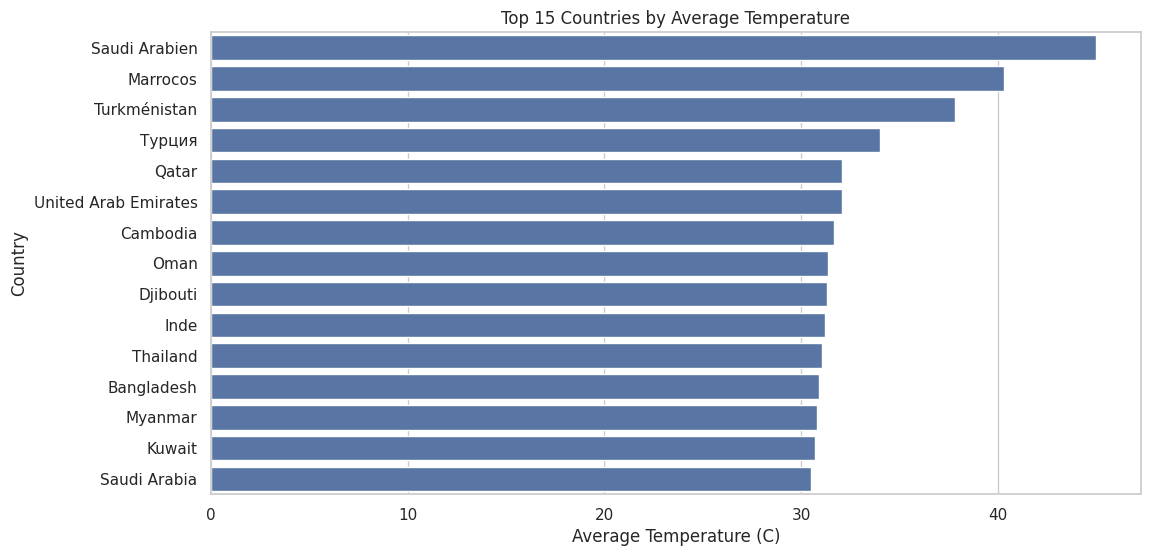

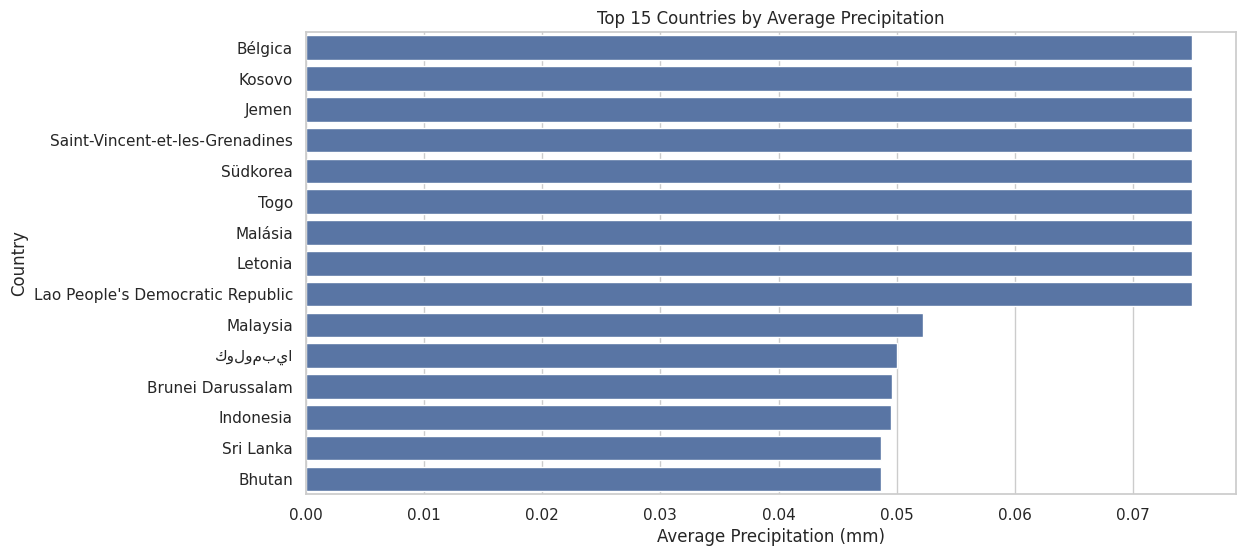

In [6]:
# =========================
# 6. Basic EDA
# =========================

# 6.1 Missing values plot
plt.figure(figsize=(14, 5))
missing_pct = (data.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
if len(missing_pct) > 0:
    sns.barplot(x=missing_pct.index, y=missing_pct.values)
    plt.xticks(rotation=90)
    plt.title("Missing Value Percentage by Column")
    plt.ylabel("% Missing")
    plt.show()
else:
    print("No missing values after cleaning.")

# 6.2 Temperature distribution
plt.figure(figsize=(12, 5))
sns.histplot(data["temperature_celsius"], bins=50, kde=True)
plt.title("Temperature Distribution (Celsius)")
plt.show()

# 6.3 Precipitation distribution
plt.figure(figsize=(12, 5))
sns.histplot(data["precip_mm"], bins=50, kde=True)
plt.title("Precipitation Distribution (mm)")
plt.show()

# 6.4 Correlation heatmap for numeric columns
plt.figure(figsize=(16, 12))
corr_cols = [c for c in numeric_cols if c in data.columns]
corr = data[corr_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# 6.5 Top weather conditions
plt.figure(figsize=(12, 5))
top_conditions = data["condition_text"].value_counts().head(15)
sns.barplot(x=top_conditions.values, y=top_conditions.index)
plt.title("Top Weather Conditions")
plt.xlabel("Count")
plt.ylabel("Condition")
plt.show()

# 6.6 Country-wise average temperature
country_temp = (
    data.groupby("country", as_index=False)["temperature_celsius"]
    .mean()
    .sort_values("temperature_celsius", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=country_temp, x="temperature_celsius", y="country")
plt.title("Top 15 Countries by Average Temperature")
plt.xlabel("Average Temperature (C)")
plt.ylabel("Country")
plt.show()

# 6.7 Country-wise average precipitation
country_precip = (
    data.groupby("country", as_index=False)["precip_mm"]
    .mean()
    .sort_values("precip_mm", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=country_precip, x="precip_mm", y="country")
plt.title("Top 15 Countries by Average Precipitation")
plt.xlabel("Average Precipitation (mm)")
plt.ylabel("Country")
plt.show()

,date,temperature_celsius,precip_mm,humidity,pressure_mb,wind_kph,air_quality_PM2.5,cloud
0,2024-05-16,23.767196,0.019352,61.679894,1013.402116,14.686508,12.612169,37.505291
1,2024-05-17,24.451648,0.021868,59.763736,1013.269231,13.989560,11.800549,34.280220
2,2024-05-18,25.355610,0.020659,58.585366,1012.853659,13.353659,11.934634,34.404878
3,2024-05-19,25.270103,0.023763,60.360825,1012.041237,13.740206,11.281959,34.649485
4,2024-05-20,25.430769,0.018846,59.610256,1012.441026,14.512821,13.278974,38.753846


Daily shape: (706, 8)


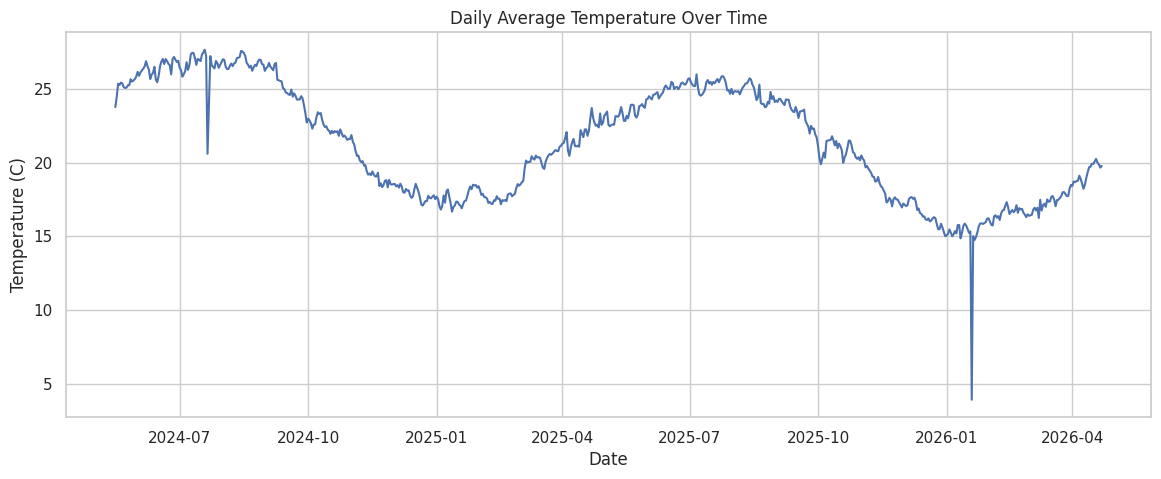

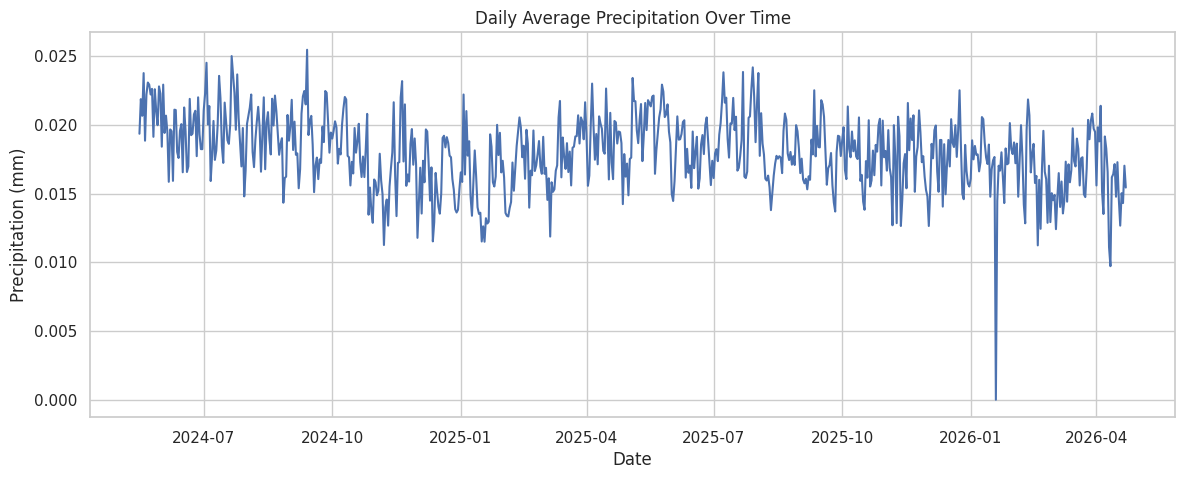

In [7]:
# =========================
# 7. TIME-SERIES AGGREGATION
# =========================

# Option A: global daily average
daily = (
    data.groupby("date", as_index=False)
    .agg({
        "temperature_celsius": "mean",
        "precip_mm": "mean",
        "humidity": "mean",
        "pressure_mb": "mean",
        "wind_kph": "mean",
        "air_quality_PM2.5": "mean",
        "cloud": "mean"
    })
    .sort_values("date")
)

display(daily.head())
print("Daily shape:", daily.shape)

plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["temperature_celsius"])
plt.title("Daily Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["precip_mm"])
plt.title("Daily Average Precipitation Over Time")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.show()

In [8]:
# =========================
# 8. OPTIONAL COUNTRY-SPECIFIC SERIES
# =========================

focus_country = "Canada"

if focus_country:
    series_data = data[data["country"] == focus_country].copy()
else:
    series_data = data.copy()

daily_series = (
    series_data.groupby("date", as_index=False)
    .agg({
        "temperature_celsius": "mean",
        "precip_mm": "mean",
        "humidity": "mean",
        "pressure_mb": "mean",
        "wind_kph": "mean",
        "air_quality_PM2.5": "mean",
        "cloud": "mean"
    })
    .sort_values("date")
    .reset_index(drop=True)
)

daily_series["dayofweek"] = daily_series["date"].dt.dayofweek
daily_series["month"] = daily_series["date"].dt.month
daily_series["dayofyear"] = daily_series["date"].dt.dayofyear

print("Series shape:", daily_series.shape)
display(daily_series.head())

Series shape: (701, 11)


,date,temperature_celsius,precip_mm,humidity,pressure_mb,wind_kph,air_quality_PM2.5,cloud,dayofweek,month,dayofyear
0,2024-05-16,14.0,0.000,67.0,1012.0,13.15,2.75,62.5,3,5,137
1,2024-05-17,20.0,0.000,78.0,1014.0,9.00,3.20,75.0,4,5,138
2,2024-05-18,18.0,0.075,88.0,1016.0,9.00,4.40,75.0,5,5,139
3,2024-05-19,18.0,0.000,77.0,1017.0,6.80,3.50,0.0,6,5,140
4,2024-05-20,23.0,0.000,69.0,1015.0,6.10,11.00,75.0,0,5,141


In [9]:
# =========================
# 9. FORECASTING FEATURES
# =========================

target_col = "temperature_celsius"

# Create lag and rolling features
for lag in [1, 7, 14]:
    daily_series[f"lag_{lag}"] = daily_series[target_col].shift(lag)

daily_series["roll_mean_7"] = daily_series[target_col].shift(1).rolling(7).mean()
daily_series["roll_std_7"] = daily_series[target_col].shift(1).rolling(7).std()

# Drop rows with NaNs caused by lagging
model_df = daily_series.dropna().reset_index(drop=True)

feature_cols = [
    "dayofweek", "month", "dayofyear",
    "lag_1", "lag_7", "lag_14",
    "roll_mean_7", "roll_std_7",
    "precip_mm", "humidity", "pressure_mb", "wind_kph", "air_quality_PM2.5", "cloud"
]

X = model_df[feature_cols]
y = model_df[target_col]

print("Model data shape:", X.shape, y.shape)
display(X.head())

Model data shape: (687, 14) (687,)


,dayofweek,month,dayofyear,lag_1,lag_7,lag_14,roll_mean_7,roll_std_7,precip_mm,humidity,pressure_mb,wind_kph,air_quality_PM2.5,cloud
0,3,5,151,11.0,19.0,14.0,16.571429,3.823486,0.0,54.0,1020.0,11.2,0.5,25.0
1,4,5,152,13.0,14.0,20.0,15.714286,3.860669,0.0,37.0,1021.0,19.1,0.6,75.0
2,5,6,153,20.0,15.0,18.0,16.571429,4.076647,0.0,49.0,1021.0,3.6,2.6,75.0
3,6,6,154,21.0,17.0,18.0,17.428571,4.314979,0.0,77.0,1017.0,6.8,10.2,100.0
4,0,6,155,17.0,23.0,23.0,17.428571,4.314979,0.0,54.0,1015.0,3.6,15.0,25.0


**Model Building**

*    Build a basic forecasting model and evaluate its performance using different metrics.
*   Use lastupdated feature for the time series analysis

In [10]:
# =========================
# 10. TRAIN / TEST SPLIT
# =========================

split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

dates_train = model_df["date"].iloc[:split_idx]
dates_test = model_df["date"].iloc[split_idx:]

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (549, 14) Test size: (138, 14)


In [11]:
# =========================
# 11. EVALUATION FUNCTION
# =========================

def evaluate_forecast(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100

    print(f"{model_name}")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print("-" * 40)

    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

In [12]:
# =========================
# 12. BASELINE (PERSISTENCE)
# =========================

# Predict tomorrow equals today's last observed temperature
baseline_pred = X_test["lag_1"].values
baseline_metrics = evaluate_forecast(y_test, baseline_pred, "Baseline Persistence")

Baseline Persistence
MAE : 1.2674
RMSE: 2.4542
R2  : 0.3187
MAPE: 326087128.44%
----------------------------------------


**Advanced Exploratory Data Analysis**

*   Implement anomaly detection to and analyze outliers

Anomalies detected: 2741


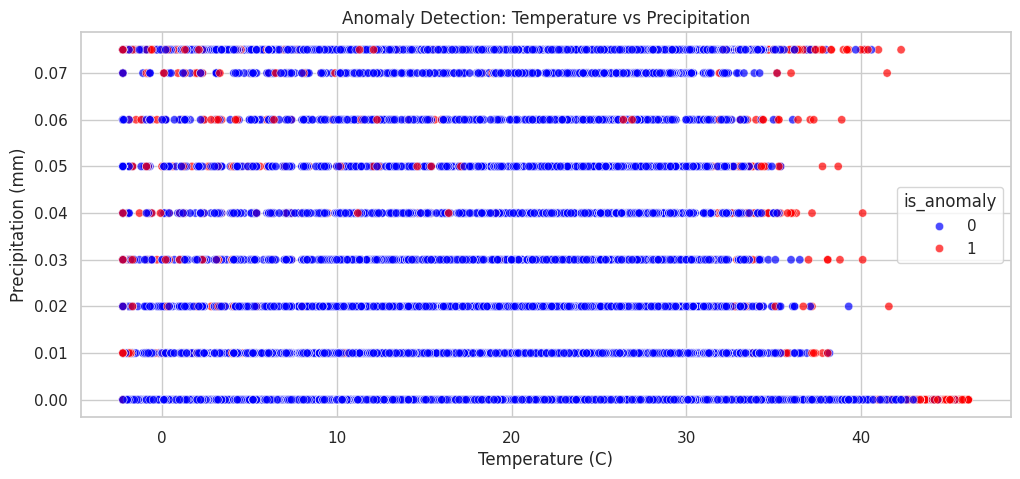

In [13]:
# =========================
# 20. ANOMALY DETECTION
# =========================

# Use a subset of numeric variables for anomaly detection
anomaly_cols = ["temperature_celsius", "precip_mm", "humidity", "pressure_mb", "wind_kph", "air_quality_PM2.5", "cloud"]

anomaly_data = data[anomaly_cols].copy()

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

anomaly_data["anomaly"] = iso.fit_predict(anomaly_data)
anomaly_data["is_anomaly"] = anomaly_data["anomaly"].map({1: 0, -1: 1})

print("Anomalies detected:", anomaly_data["is_anomaly"].sum())

plt.figure(figsize=(12, 5))
sns.scatterplot(
    x=data["temperature_celsius"],
    y=data["precip_mm"],
    hue=anomaly_data["is_anomaly"],
    palette={0: "blue", 1: "red"},
    alpha=0.7
)
plt.title("Anomaly Detection: Temperature vs Precipitation")
plt.xlabel("Temperature (C)")
plt.ylabel("Precipitation (mm)")
plt.show()

**Forecasting with Multiple Models**

*   Build and compare multiple forecasting models
*   Create an ensemble of models to improve forecast accuracy

In [14]:
# =========================
# 13. LINEAR REGRESSION
# =========================

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_metrics = evaluate_forecast(y_test, lr_pred, "Linear Regression")

Linear Regression
MAE : 1.6782
RMSE: 2.3318
R2  : 0.3850
MAPE: 284281387.09%
----------------------------------------


In [15]:
# =========================
# 14. RANDOM FOREST
# =========================

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_metrics = evaluate_forecast(y_test, rf_pred, "Random Forest")

Random Forest
MAE : 1.3664
RMSE: 2.2950
R2  : 0.4042
MAPE: 271868908.51%
----------------------------------------


In [16]:
# =========================
# 15. GRADIENT BOOSTING
# =========================

gbr = GradientBoostingRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

gbr_metrics = evaluate_forecast(y_test, gbr_pred, "Gradient Boosting")

Gradient Boosting
MAE : 1.4523
RMSE: 2.3059
R2  : 0.3986
MAPE: 292003325.62%
----------------------------------------


In [17]:
# =========================
# 16. ENSEMBLE FORECAST
# =========================

ensemble_pred = (lr_pred + rf_pred + gbr_pred) / 3
ensemble_metrics = evaluate_forecast(y_test, ensemble_pred, "Simple Ensemble")

Simple Ensemble
MAE : 1.4200
RMSE: 2.1591
R2  : 0.4727
MAPE: 282717867.43%
----------------------------------------


In [18]:
# =========================
# 17. MODEL COMPARISON TABLE
# =========================

results = pd.DataFrame([
    baseline_metrics,
    lr_metrics,
    rf_metrics,
    gbr_metrics,
    ensemble_metrics
])

display(results.sort_values("RMSE"))

,Model,MAE,RMSE,R2,MAPE
4,Simple Ensemble,1.420036,2.159073,0.472722,2.827179e+08
2,Random Forest,1.366405,2.295008,0.404237,2.718689e+08
3,Gradient Boosting,1.452265,2.305884,0.398577,2.920033e+08
1,Linear Regression,1.678163,2.331757,0.385005,2.842814e+08
0,Baseline Persistence,1.267391,2.454159,0.318744,3.260871e+08


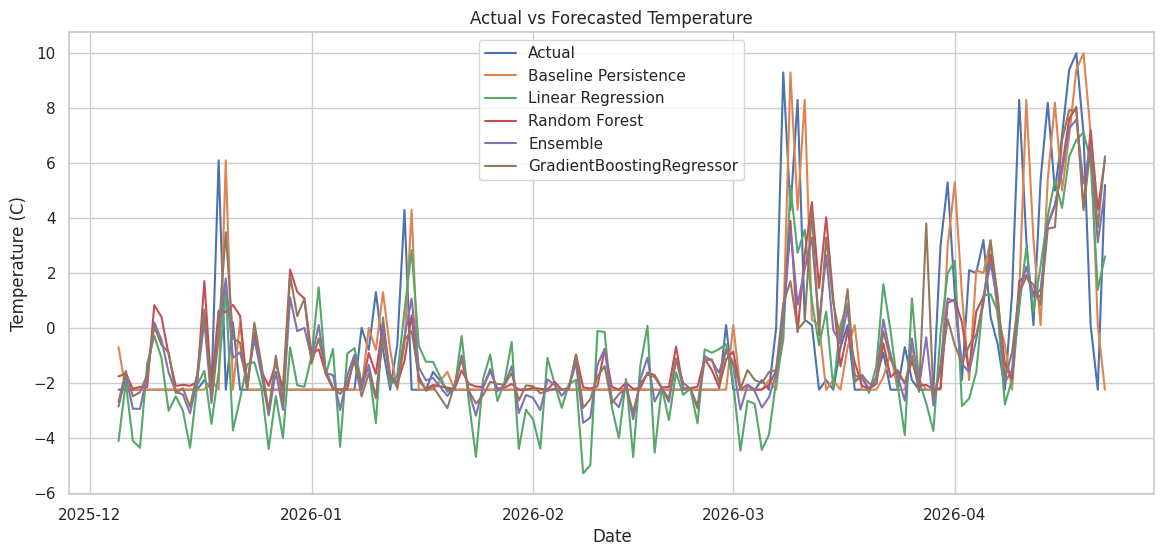

In [19]:
# =========================
# 18. PREDICTION PLOT
# =========================

plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test.values, label="Actual")
plt.plot(dates_test, baseline_pred, label="Baseline Persistence")
plt.plot(dates_test, lr_pred, label="Linear Regression")
plt.plot(dates_test, rf_pred, label="Random Forest")
plt.plot(dates_test, ensemble_pred, label="Ensemble")
plt.plot(dates_test, gbr_pred, label="GradientBoostingRegressor")

plt.title("Actual vs Forecasted Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.show()

**Unique Analyses**

*   Climate Analysis: Study long-term climate patterns and variations in different regions.

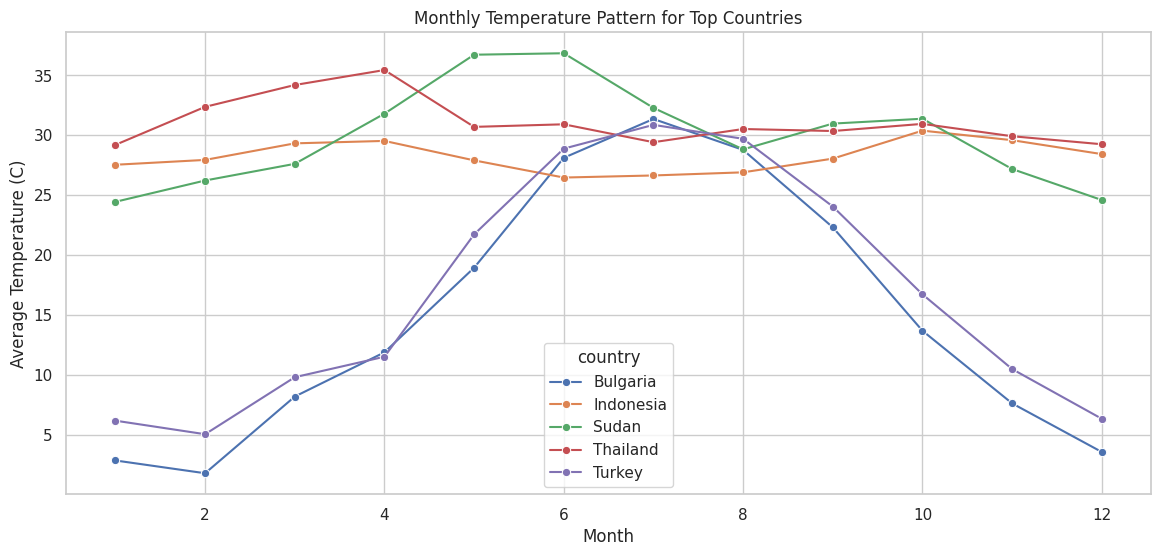

In [20]:
# =========================
# 21. CLIMATE PATTERN ANALYSIS
# =========================

monthly_climate = (
    data.groupby(["country", "month"], as_index=False)
    .agg({
        "temperature_celsius": "mean",
        "precip_mm": "mean",
        "humidity": "mean"
    })
)

# Example: climate trend for the top 5 countries by row count
top_countries = data["country"].value_counts().head(5).index.tolist()
monthly_climate_top = monthly_climate[monthly_climate["country"].isin(top_countries)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_climate_top, x="month", y="temperature_celsius", hue="country", marker="o")
plt.title("Monthly Temperature Pattern for Top Countries")
plt.xlabel("Month")
plt.ylabel("Average Temperature (C)")
plt.show()

*   Environmental Impact: Analyze air quality and its correlation with various weather parameters.

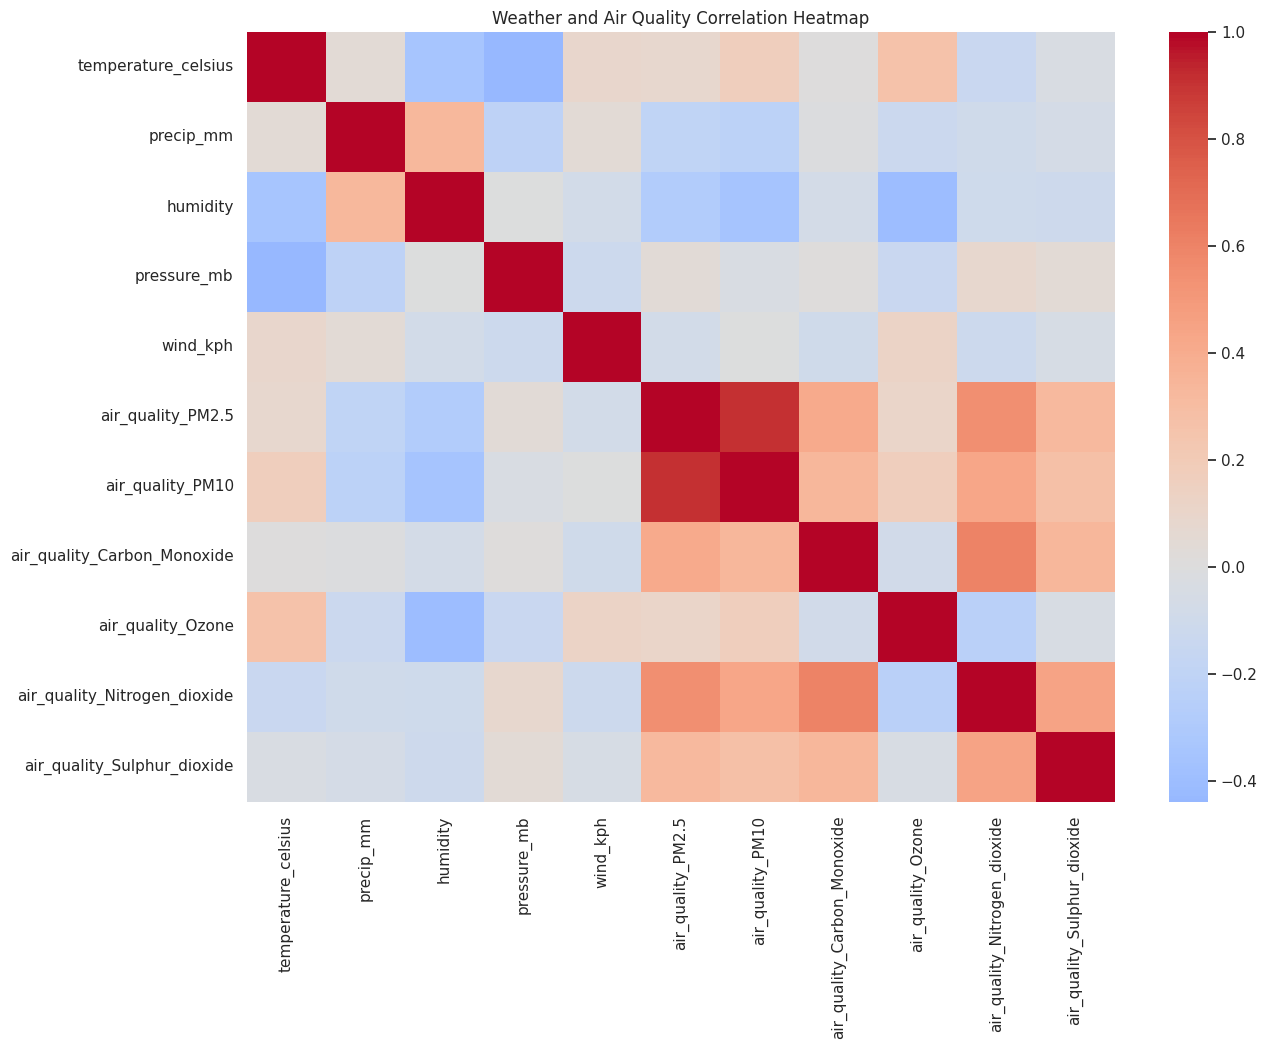

In [21]:
# =========================
# 22. AIR QUALITY ANALYSIS
# =========================

aq_cols = [
    "temperature_celsius", "precip_mm", "humidity", "pressure_mb", "wind_kph",
    "air_quality_PM2.5", "air_quality_PM10", "air_quality_Carbon_Monoxide",
    "air_quality_Ozone", "air_quality_Nitrogen_dioxide", "air_quality_Sulphur_dioxide"
]

aq_corr = data[aq_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(aq_corr, cmap="coolwarm", center=0)
plt.title("Weather and Air Quality Correlation Heatmap")
plt.show()


*   Feature Importance: Apply different techniques to assess feature importance


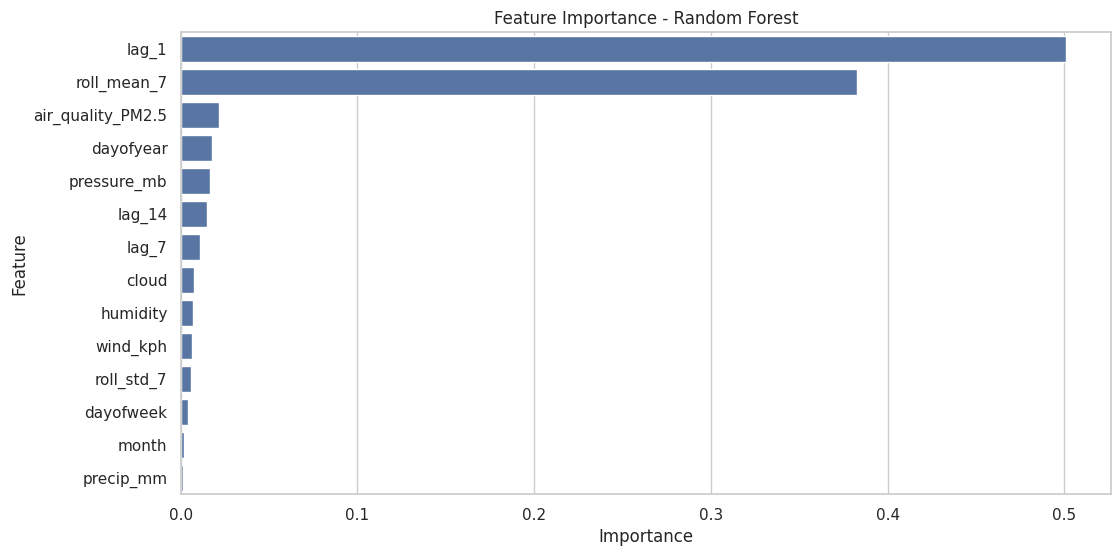

,0
lag_1,0.501181
roll_mean_7,0.382824
air_quality_PM2.5,0.021620
dayofyear,0.017837
pressure_mb,0.016677
lag_14,0.014901
lag_7,0.011112
cloud,0.007572
humidity,0.007094
wind_kph,0.006541


In [22]:
# =========================
# 19. FEATURE IMPORTANCE
# =========================

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

display(importances)



*   Spatial Analysis: Analyze and visualize geographical patterns in the data.

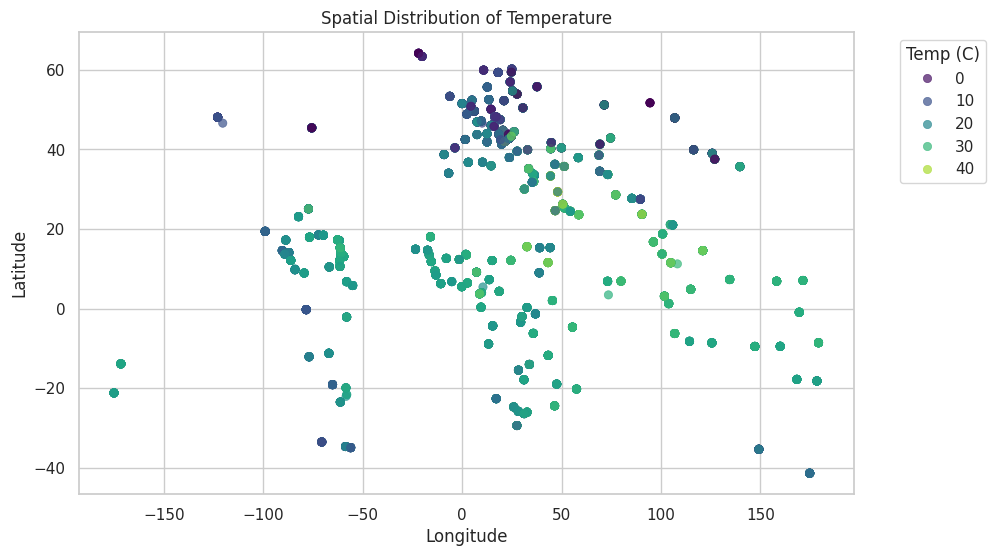

In [23]:
# =========================
# 23. SPATIAL ANALYSIS
# =========================

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data.sample(min(5000, len(data)), random_state=42),
    x="longitude",
    y="latitude",
    hue="temperature_celsius",
    palette="viridis",
    alpha=0.7,
    edgecolor=None
)
plt.title("Spatial Distribution of Temperature")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Temp (C)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

*   Geographical Patterns: Explore how weather conditions differ across countries and continents.

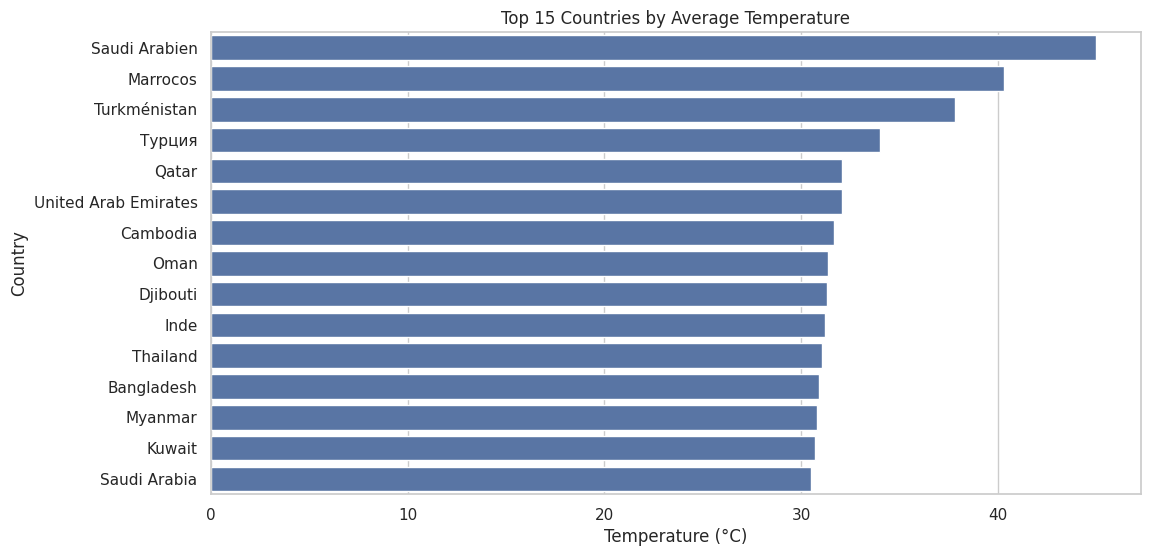

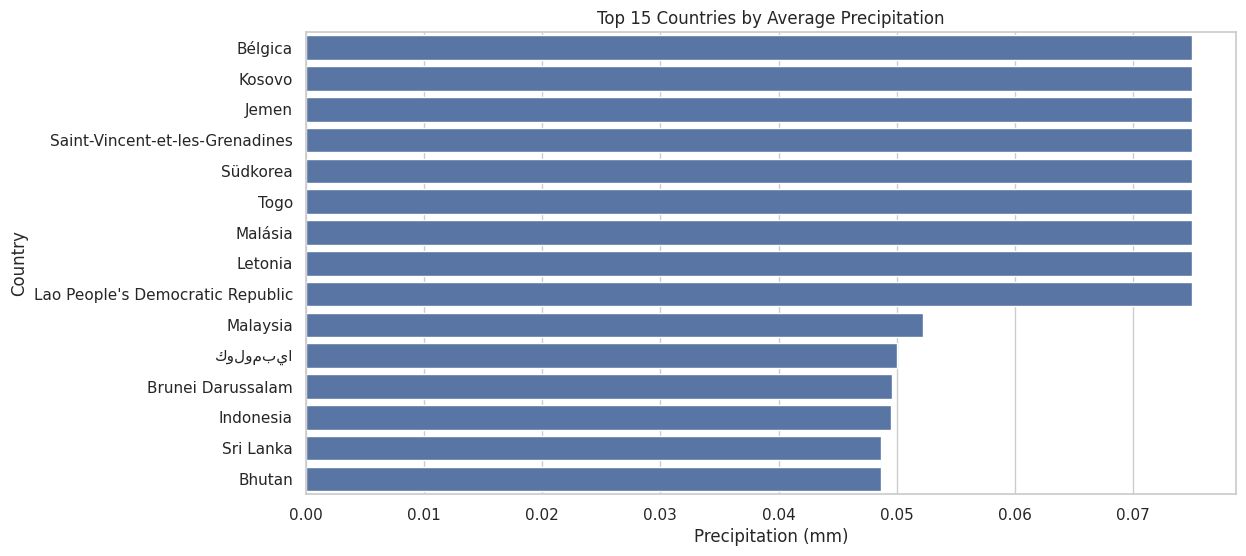

In [24]:
# =========================
# 24. GEOGRAPHICAL PATTERNS ANALYSIS
# =========================
# -------------------------
# 1. COUNTRY-LEVEL SUMMARY
# -------------------------
country_summary = (
    data.groupby("country", as_index=False)
    .agg(
        avg_temp=("temperature_celsius", "mean"),
        avg_precip=("precip_mm", "mean"),
        avg_humidity=("humidity", "mean"),
        count=("country", "size")
    )
)

# Top hot countries
top_temp = country_summary.sort_values("avg_temp", ascending=False).head(15)

plt.figure()
sns.barplot(data=top_temp, x="avg_temp", y="country")
plt.title("Top 15 Countries by Average Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Country")
plt.show()

# Top rainy countries
top_rain = country_summary.sort_values("avg_precip", ascending=False).head(15)

plt.figure()
sns.barplot(data=top_rain, x="avg_precip", y="country")
plt.title("Top 15 Countries by Average Precipitation")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Country")
plt.show()

,continent,avg_temp,avg_precip,avg_humidity,count
0,Africa,25.263762,0.016156,62.089231,35862
1,America,20.994161,0.018449,83.503795,24508
2,Asia,24.186574,0.017420,52.784563,34864
3,Europe,13.241058,0.015449,70.208744,31929
4,Oceania,24.995596,0.034821,81.810722,9140


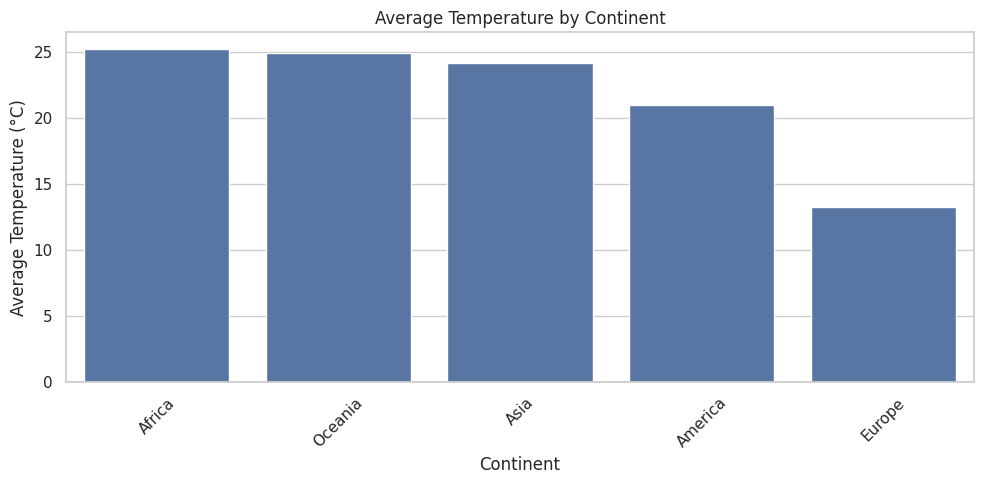

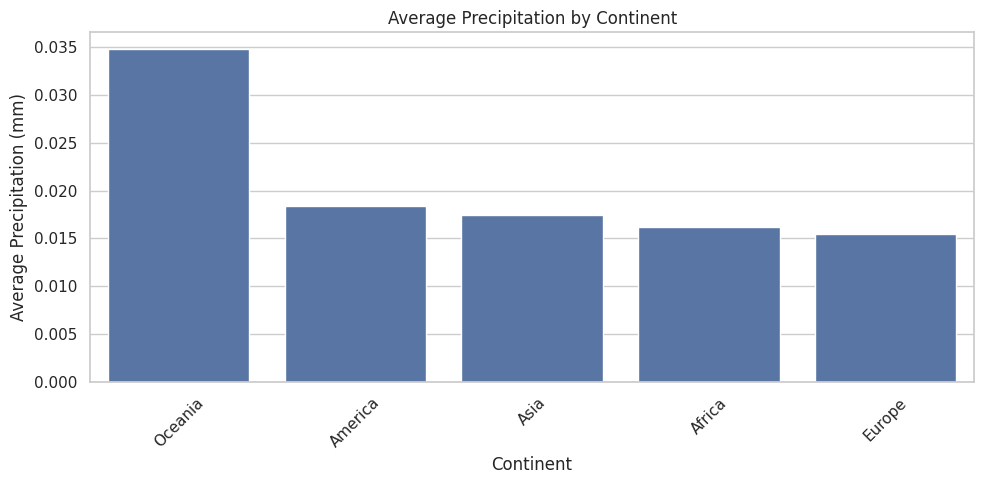

In [25]:
# -------------------------
# 2. CONTINENT LEVEL SUMMARY
# -------------------------
cc = coco.CountryConverter()


def get_continent(country):
    if pd.isna(country):
        return "Unknown"

    country = str(country).strip()

    cont = cc.convert(names=country, to="continent")

    if cont in ["not found", None, "", "nan"]:
        return "Unknown"
    return cont

data["continent"] = data["country"].apply(get_continent)

continent_summary = (
    data[data["continent"] != "Unknown"]
    .groupby("continent", as_index=False)
    .agg(
        avg_temp=("temperature_celsius", "mean"),
        avg_precip=("precip_mm", "mean"),
        avg_humidity=("humidity", "mean"),
        count=("continent", "size")
    )
)

display(continent_summary)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=continent_summary.sort_values("avg_temp", ascending=False),
    x="continent", y="avg_temp"
)
plt.title("Average Temperature by Continent")
plt.xlabel("Continent")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=continent_summary.sort_values("avg_precip", ascending=False),
    x="continent", y="avg_precip"
)
plt.title("Average Precipitation by Continent")
plt.xlabel("Continent")
plt.ylabel("Average Precipitation (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

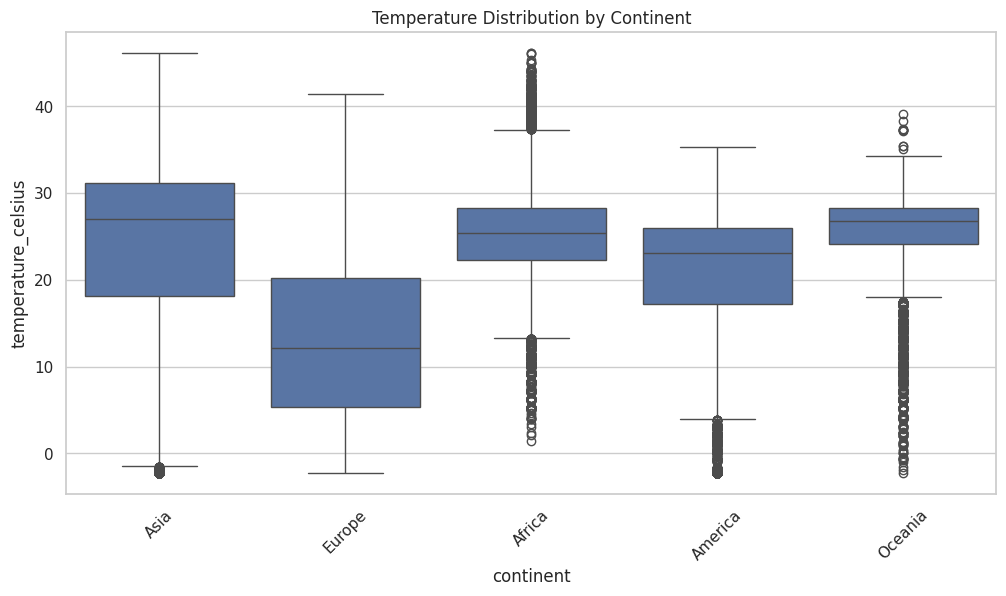

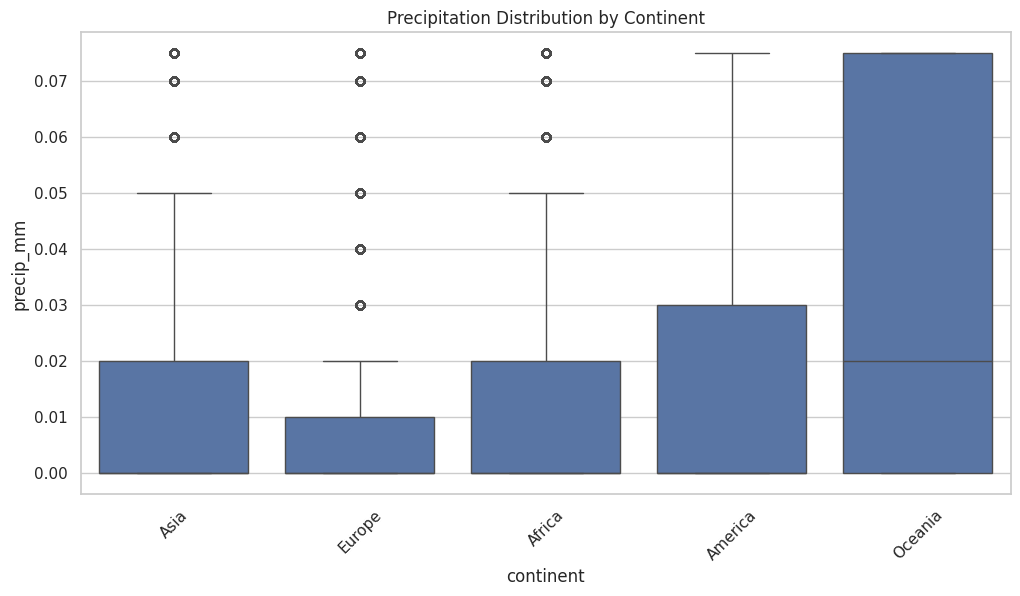

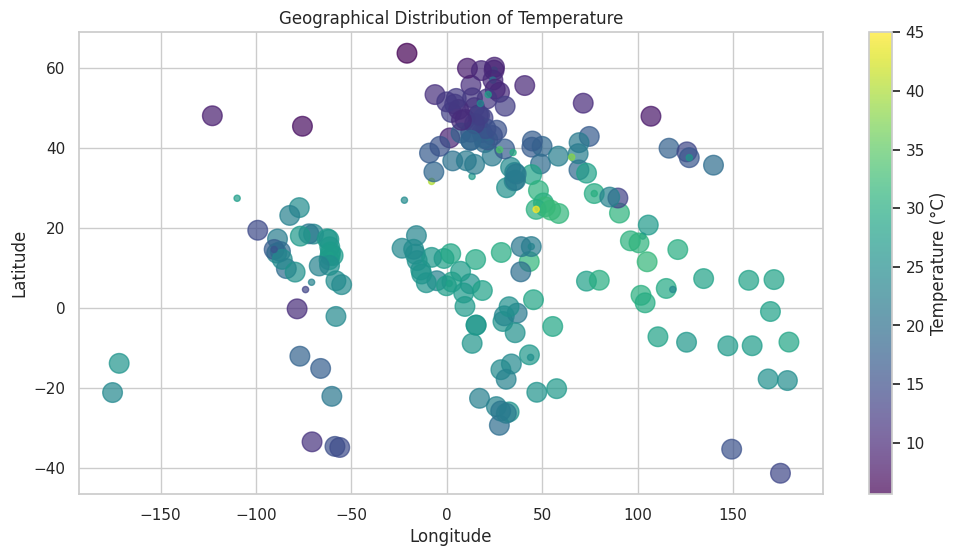

In [26]:
# -------------------------
# 3. DISTRIBUTIONS
# -------------------------
plt.figure()
sns.boxplot(data=data[data["continent"] != "Unknown"],
            x="continent", y="temperature_celsius")
plt.title("Temperature Distribution by Continent")
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.boxplot(data=data[data["continent"] != "Unknown"],
            x="continent", y="precip_mm")
plt.title("Precipitation Distribution by Continent")
plt.xticks(rotation=45)
plt.show()


# -------------------------
# 4. GEO SPATIAL SCATTER
# -------------------------
geo = (
    data.groupby("country", as_index=False)
    .agg(
        lat=("latitude", "mean"),
        lon=("longitude", "mean"),
        temp=("temperature_celsius", "mean"),
        count=("country", "size")
    )
)

plt.figure(figsize=(12,6))
sc = plt.scatter(
    geo["lon"],
    geo["lat"],
    c=geo["temp"],
    s=np.clip(geo["count"], 20, 200),
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(sc, label="Temperature (°C)")
plt.title("Geographical Distribution of Temperature")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [27]:
# =========================
# 25. SAVE OUTPUTS
# =========================

results.to_csv("model_comparison_results.csv", index=False)
data.to_csv("cleaned_weather_data.csv", index=False)

print("Saved model_comparison_results.csv and cleaned_weather_data.csv")

Saved model_comparison_results.csv and cleaned_weather_data.csv
